In [ ]:
import pandas as pd
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
import plotly.graph_objects as go
from prophet import Prophet
import matplotlib.pyplot as plt
import plotly.express as px

file_path = r"C:\Users\karth\OneDrive\Desktop\Trent\Final Project AMOD\All Deliverables\Final Project\Deliverables\Final SMAIR Dataset.xlsx"
excel_file = pd.ExcelFile(file_path)
sheet_names = excel_file.sheet_names
print("Sheet names:", sheet_names)

identification_df = excel_file.parse('Identification')
schedule_of_funding_df = excel_file.parse('Schedule of Funding')
service_level_standards_df = excel_file.parse('Service Level Standards')
municipally_funded_tenant_rent_df = excel_file.parse('Municipally Funded Tenant Rent')
centralized_waiting_list_inform_df = excel_file.parse('Centralized Waiting List Inform')
cwl_2020_2021_df = excel_file.parse('CWL 2020 & 2021')
cwl_household_2020_onwards_df = excel_file.parse('CWL Household 2020 and onwards')
rent_supplement_df = excel_file.parse('Rent Supplement')

Sheet names: ['Identification', 'Schedule of Funding', 'FF', 'Service Level Standards', 'FSL', 'Municipally Funded Tenant Rent', 'Centralized Waiting List Inform', 'CWLF', 'CWL 2020 & 2021', 'CWL Household 2020 and onwards', 'Rent Supplement']


In [ ]:
schedule_of_funding_df = schedule_of_funding_df.fillna(0)
service_level_standards_df = service_level_standards_df.fillna(0)
rent_supplement_df = rent_supplement_df.fillna(0)
convert = [ 'Average wait-time to be housed in an RGI unit (in months)', 
           'Average wait-time to receive an offer of housing through COHB or PHB (in months)' ] 
cwl_household_2020_onwards_df[convert] = cwl_household_2020_onwards_df[convert].astype(float)
identification_df = identification_df.drop(columns=['No.'])

https://www.geeksforgeeks.org/steps-for-mastering-exploratory-data-analysis-eda-steps/
https://plotly.com/python-api-reference/generated/plotly.subplots.make_subplots.html

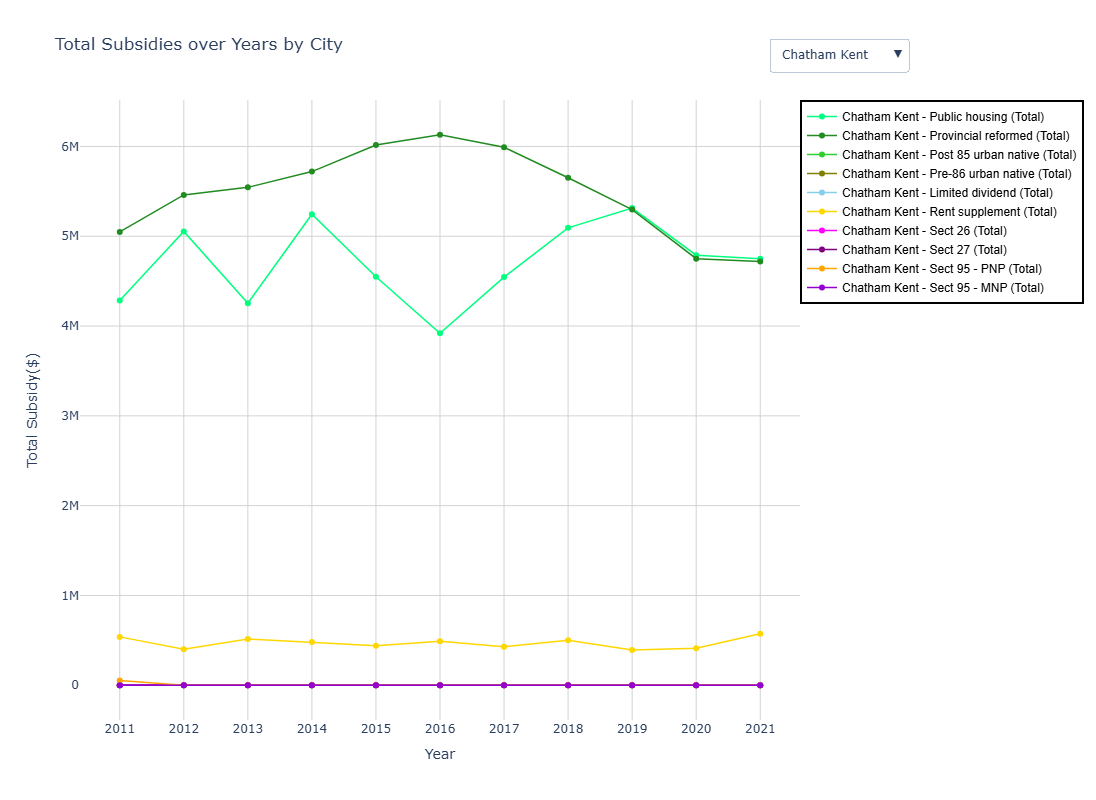

In [ ]:
schedule_of_funding_df['Subsidy Type'] = schedule_of_funding_df['Subsidy Type'].str.replace('\xa0', ' ')
df_melted = schedule_of_funding_df.melt(id_vars=['Year', 'Subsidy Type', 'City'], var_name='Program Type', value_name='Value')
df_melted['Program Type'] = df_melted['Program Type'].str.replace('\xa0', ' ')
color_map = {
    'Public housing': 'springgreen',
    'Provincial reformed': '#228B22',  # Forest Green
    'Post 85 urban native': 'limegreen',
    'Pre-86 urban native': 'olive',
    'Limited dividend': 'skyblue',
    'Rent supplement': 'gold',
    'Sect 26': 'magenta',
    'Sect 27': 'purple',
    'Sect 95 - PNP': 'orange',
    'Sect 95 - MNP': 'darkviolet'
}

def add_traces(fig, df, color_map):
    for city in df['City'].unique():
        city_data = df[df['City'] == city]
        for program_type in color_map.keys():
            program_data = city_data[(city_data['Program Type'] == program_type) & (city_data['Subsidy Type'] == 'Total')]
            if not program_data.empty:
                fig.add_trace(go.Scatter(
                    x=program_data['Year'],
                    y=program_data['Value'],
                    mode='lines+markers',
                    name=f"{city} - {program_type} (Total)",
                    line=dict(color=color_map[program_type], width=1.5),
                    visible=(city == df['City'].unique()[0])
                ))
fig_total = go.Figure()
add_traces(fig_total, df_melted, color_map)

visibility_settings = []
for city in df_melted['City'].unique():
    visibility = [trace.name.startswith(city) for trace in fig_total.data]
    visibility_settings.append(visibility)

fig_total.update_layout(
    title='Total Subsidies over Years by City',
    xaxis_title='Year',
    yaxis_title='Total Subsidy($)',
    yaxis=dict(tickmode='linear', tick0=0, dtick=1000000, showgrid=True, gridcolor='lightgrey'),
    xaxis=dict(tickmode='linear', tick0=2010, dtick=1, showgrid=True, gridcolor='lightgrey'),
    plot_bgcolor='white',
    paper_bgcolor='white',
    width=1000,
    height=800,
    legend=dict(
        x=1,
        y=1,
        traceorder='normal',
        font=dict(
            family='sans-serif',
            size=12,
            color='black'
        ),
        bgcolor='white',
        bordercolor='black',
        borderwidth=2
    ),
    updatemenus=[
        {
            'buttons': [
                {
                    'label': city,
                    'method': 'update',
                    'args': [
                        {'visible': visibility},
                        {'title': f"Total Subsidies over Years in {city}"}
                    ]
                } for city, visibility in zip(df_melted['City'].unique(), visibility_settings)
            ],
            'direction': 'down',
            'showactive': True,
            'x': 1.15,
            'y': 1.1
        }
    ]
)

fig_total.show()

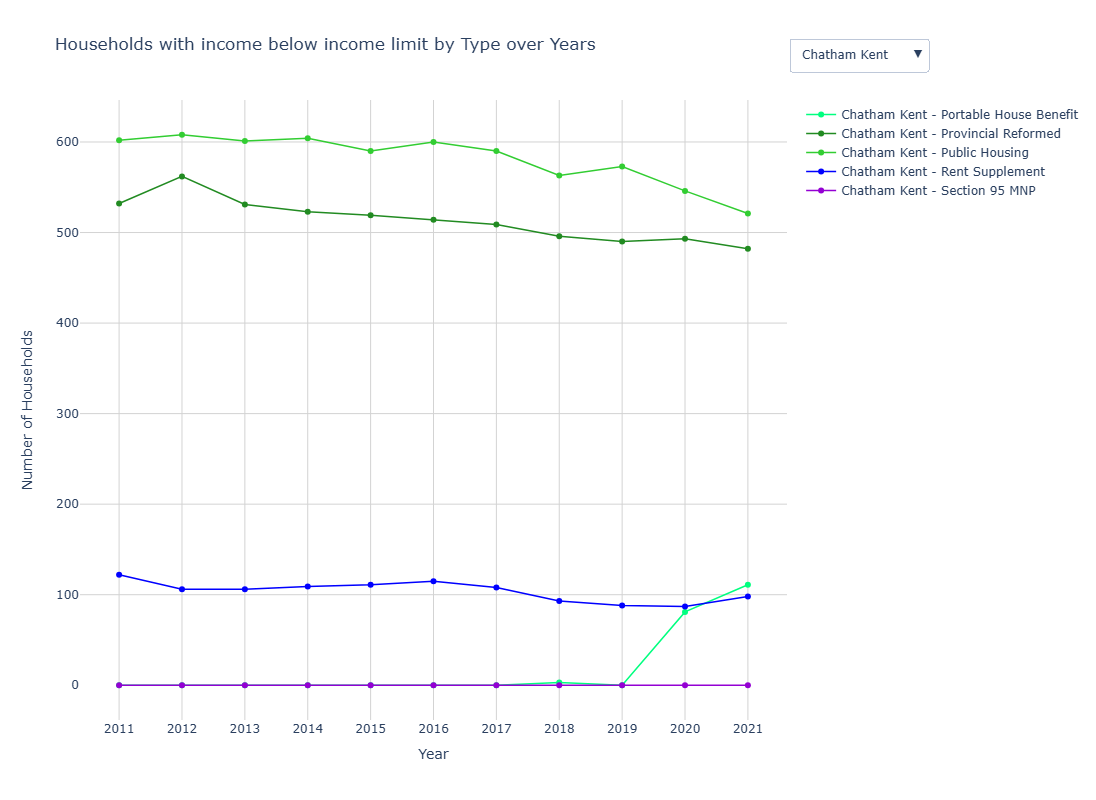

In [ ]:
service_level_standards_df['Type of Households'] = service_level_standards_df['Type of Households'].str.replace('\xa0', '')
type = service_level_standards_df['Type of Households'].unique()
color_map = {
    'Portable House Benefit': 'springgreen',
    'Provincial Reformed': '#228B22',  # Forest Green
    'Public Housing': 'limegreen',
    'Rent Supplement ': 'blue',
    'Section 95 MNP': 'darkviolet'
}

fig_high_need = go.Figure()
for city in service_level_standards_df['City'].unique():
    city_data = service_level_standards_df[service_level_standards_df['City'] == city]
    for household_type in type:
        household_data = city_data[city_data['Type of Households'] == household_type]
        if not household_data.empty:
            fig_high_need.add_trace(go.Scatter(
                x=household_data['Year'],
                y=household_data['Households with income below income limit'],
                mode='lines+markers',
                name=f"{city} - {household_type}",
                line=dict(color=color_map[household_type], width=1.5),
                visible=(city == service_level_standards_df['City'].unique()[0])
            ))

visibility_settings = []
for city in service_level_standards_df['City'].unique():
    visibility = [trace.name.startswith(city) for trace in fig_high_need.data]
    visibility_settings.append(visibility)

fig_high_need.update_layout(
    title='Households with income below income limit by Type over Years',
    xaxis_title='Year',
    yaxis_title='Number of Households',
    yaxis=dict(tickmode='linear', tick0=0, dtick=100, showgrid=True, gridcolor='lightgrey'),
    xaxis=dict(tickmode='linear', tick0=2010, dtick=1, showgrid=True, gridcolor='lightgrey'),
    plot_bgcolor='white',
    paper_bgcolor='white',
    width=1000,
    height=800,
    updatemenus=[
        {
            'buttons': [
                {
                    'label': city,
                    'method': 'update',
                    'args': [
                        {'visible': [trace.name.startswith(city) for trace in fig_high_need.data]},
                        {'title': f"Households with income below income limit by Type over Years in {city}"}
                    ]
                } for city in service_level_standards_df['City'].unique()
            ],
            'direction': 'down',
            'showactive': True,
            'x': 1.2,
            'y': 1.1
        }
    ]
)
fig_high_need.show()

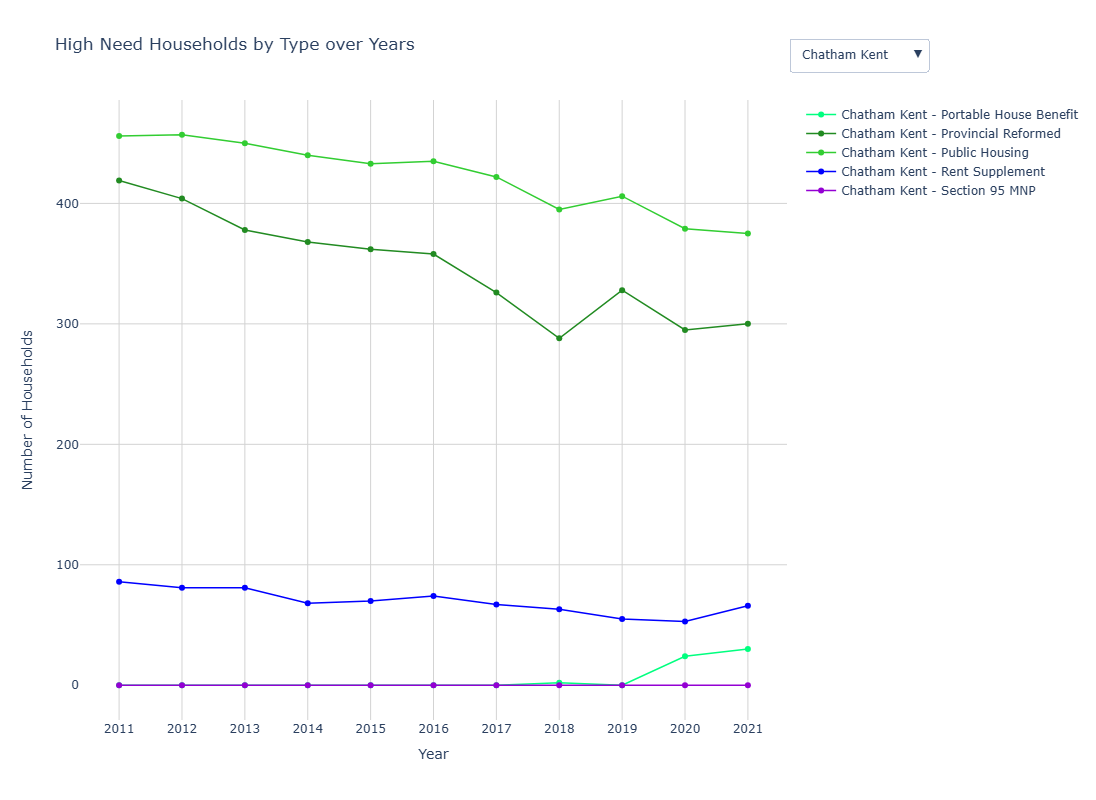

In [ ]:
service_level_standards_df['Type of Households'] = service_level_standards_df['Type of Households'].str.replace('\xa0', '')
type = service_level_standards_df['Type of Households'].unique()
color_map = {
    'Portable House Benefit': 'springgreen',
    'Provincial Reformed': '#228B22',  # Forest Green
    'Public Housing': 'limegreen',
    'Rent Supplement ': 'blue',
    'Section 95 MNP': 'darkviolet'
}

fig_high_need = go.Figure()
for city in service_level_standards_df['City'].unique():
    city_data = service_level_standards_df[service_level_standards_df['City'] == city]
    for household_type in type:
        household_data = city_data[city_data['Type of Households'] == household_type]
        if not household_data.empty:
            fig_high_need.add_trace(go.Scatter(
                x=household_data['Year'],
                y=household_data['High need households'],
                mode='lines+markers',
                name=f"{city} - {household_type}",
                line=dict(color=color_map[household_type], width=1.5),
                visible=(city == service_level_standards_df['City'].unique()[0])
            ))

visibility_settings = []
for city in service_level_standards_df['City'].unique():
    visibility = [trace.name.startswith(city) for trace in fig_high_need.data]
    visibility_settings.append(visibility)

fig_high_need.update_layout(
    title='High Need Households by Type over Years',
    xaxis_title='Year',
    yaxis_title='Number of Households',
    yaxis=dict(tickmode='linear', tick0=0, dtick=100, showgrid=True, gridcolor='lightgrey'),
    xaxis=dict(tickmode='linear', tick0=2010, dtick=1, showgrid=True, gridcolor='lightgrey'), 
    plot_bgcolor='white',
    paper_bgcolor='white',
    width=1000,
    height=800,
    updatemenus=[
        {
            'buttons': [
                {
                    'label': city,
                    'method': 'update',
                    'args': [
                        {'visible': [trace.name.startswith(city) for trace in fig_high_need.data]},
                        {'title': f"High Need Households by Type over Years in {city}"}
                    ]
                } for city in service_level_standards_df['City'].unique()
            ],
            'direction': 'down',
            'showactive': True,
            'x': 1.2,
            'y': 1.1
        }
    ]
)

fig_high_need.show()

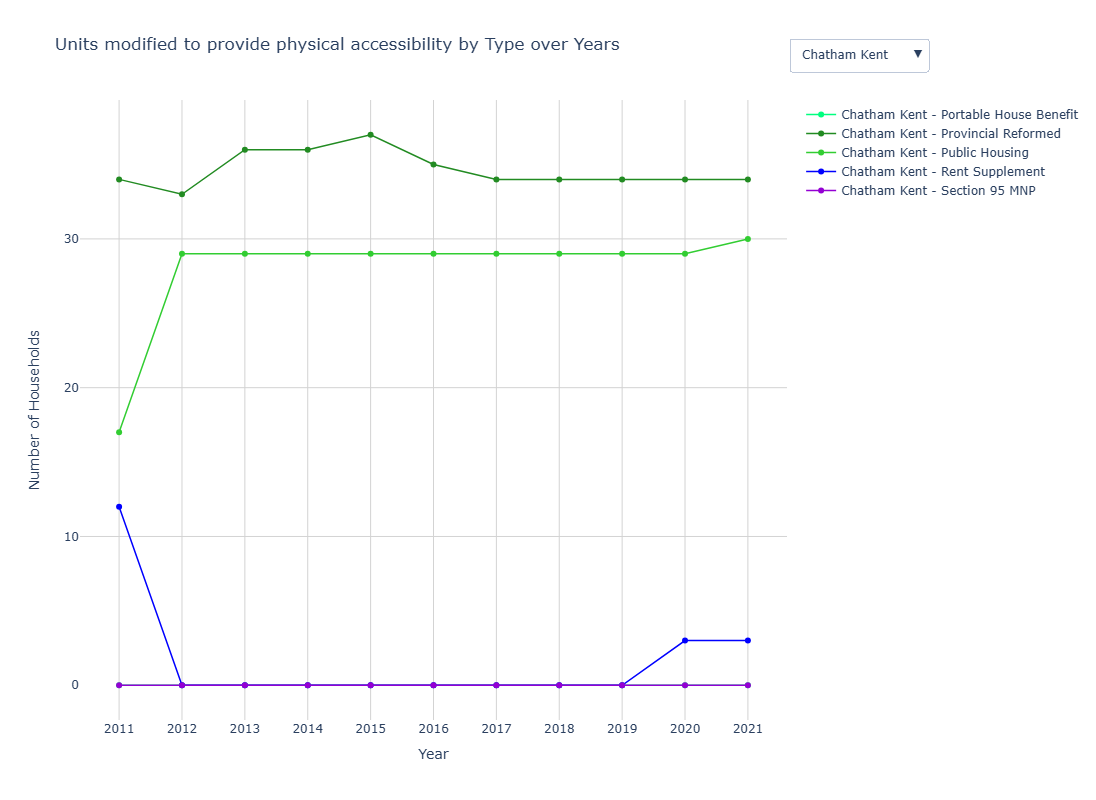

In [ ]:
service_level_standards_df['Type of Households'] = service_level_standards_df['Type of Households'].str.replace('\xa0', '')
type = service_level_standards_df['Type of Households'].unique()
color_map = {
    'Portable House Benefit': 'springgreen',
    'Provincial Reformed': '#228B22',  # Forest Green
    'Public Housing': 'limegreen',
    'Rent Supplement ': 'blue',
    'Section 95 MNP': 'darkviolet'
}

fig_high_need = go.Figure()
for city in service_level_standards_df['City'].unique():
    city_data = service_level_standards_df[service_level_standards_df['City'] == city]
    for household_type in type:
        household_data = city_data[city_data['Type of Households'] == household_type]
        if not household_data.empty:
            fig_high_need.add_trace(go.Scatter(
                x=household_data['Year'],
                y=household_data['Units modified to provide physical accessibility'],
                mode='lines+markers',
                name=f"{city} - {household_type}",
                line=dict(color=color_map[household_type], width=1.5),
                visible=(city == service_level_standards_df['City'].unique()[0])
            ))

visibility_settings = []
for city in service_level_standards_df['City'].unique():
    visibility = [trace.name.startswith(city) for trace in fig_high_need.data]
    visibility_settings.append(visibility)

fig_high_need.update_layout(
    title='Units modified to provide physical accessibility by Type over Years',
    xaxis_title='Year',
    yaxis_title='Number of Households',
    yaxis=dict(tickmode='linear', tick0=0, dtick=10, showgrid=True, gridcolor='lightgrey'),
    xaxis=dict(tickmode='linear', tick0=2010, dtick=1, showgrid=True, gridcolor='lightgrey'),
    plot_bgcolor='white',
    paper_bgcolor='white',
    width=1000,
    height=800,
    updatemenus=[
        {
            'buttons': [
                {
                    'label': city,
                    'method': 'update',
                    'args': [
                        {'visible': [trace.name.startswith(city) for trace in fig_high_need.data]},
                        {'title': f"Units modified to provide physical accessibility by Type over Years in {city}"}
                    ]
                } for city in service_level_standards_df['City'].unique()
            ],
            'direction': 'down',
            'showactive': True,
            'x': 1.2,
            'y': 1.1 
        }
    ]
)

fig_high_need.show()

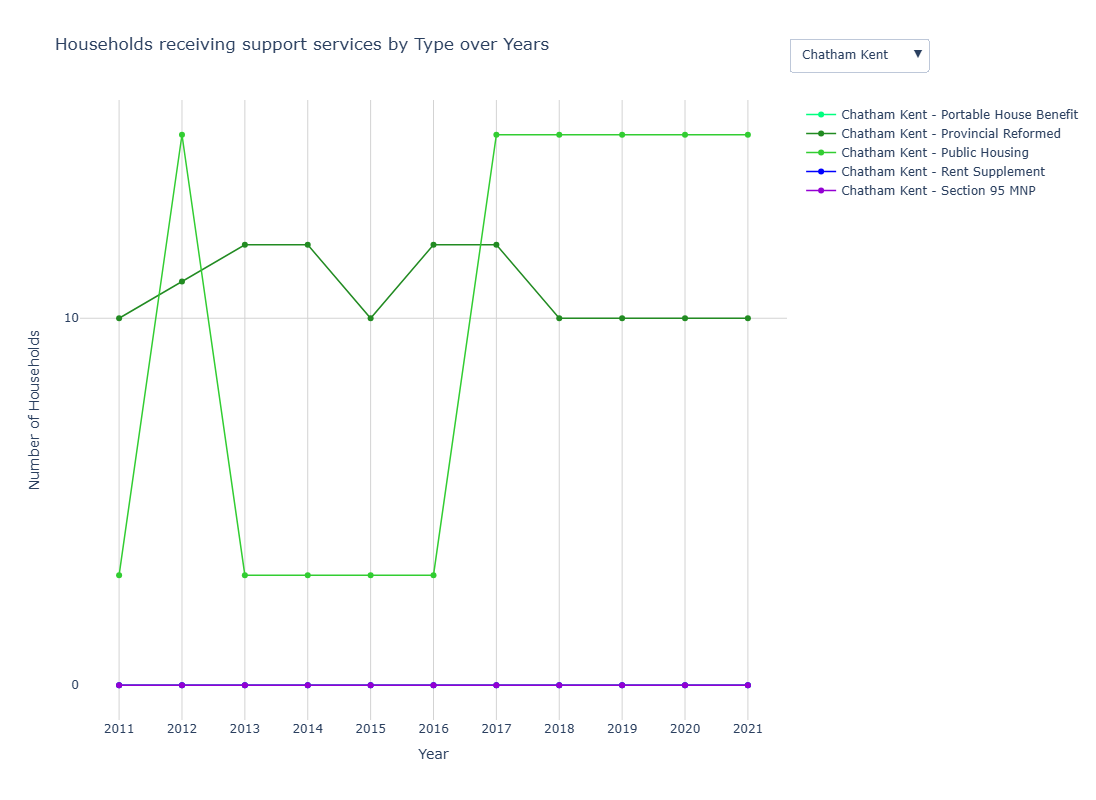

In [ ]:
service_level_standards_df['Type of Households'] = service_level_standards_df['Type of Households'].str.replace('\xa0', '')
type = service_level_standards_df['Type of Households'].unique()
color_map = {
    'Portable House Benefit': 'springgreen',
    'Provincial Reformed': '#228B22',  # Forest Green
    'Public Housing': 'limegreen',
    'Rent Supplement ': 'blue',
    'Section 95 MNP': 'darkviolet'
}

fig_high_need = go.Figure()
for city in service_level_standards_df['City'].unique():
    city_data = service_level_standards_df[service_level_standards_df['City'] == city]
    for household_type in type:
        household_data = city_data[city_data['Type of Households'] == household_type]
        if not household_data.empty:
            fig_high_need.add_trace(go.Scatter(
                x=household_data['Year'],
                y=household_data['Households receiving support services'],
                mode='lines+markers',
                name=f"{city} - {household_type}",
                line=dict(color=color_map[household_type], width=1.5),
                visible=(city == service_level_standards_df['City'].unique()[0])
            ))

visibility_settings = []
for city in service_level_standards_df['City'].unique():
    visibility = [trace.name.startswith(city) for trace in fig_high_need.data]
    visibility_settings.append(visibility)

fig_high_need.update_layout(
    title='Households receiving support services by Type over Years',
    xaxis_title='Year',
    yaxis_title='Number of Households',
    yaxis=dict(tickmode='linear', tick0=0, dtick=10, showgrid=True, gridcolor='lightgrey'),
    xaxis=dict(tickmode='linear', tick0=2010, dtick=1, showgrid=True, gridcolor='lightgrey'),
    plot_bgcolor='white',
    paper_bgcolor='white',
    width=1000,
    height=800,
    updatemenus=[
        {
            'buttons': [
                {
                    'label': city,
                    'method': 'update',
                    'args': [
                        {'visible': [trace.name.startswith(city) for trace in fig_high_need.data]},
                        {'title': f"Households receiving support services by Type over Years in {city}"}
                    ]
                } for city in service_level_standards_df['City'].unique()
            ],
            'direction': 'down',
            'showactive': True,
            'x': 1.2,
            'y': 1.1
        }
    ]
)
fig_high_need.show()

In [ ]:
municipally_funded_tenant_rent_df = municipally_funded_tenant_rent_df.dropna()

In [ ]:
municipally_funded_tenant_rent_df["City"].unique()

array(['Peterborough', 'Simcoe', 'York', 'Northumberland', 'Chatham Kent',
       'Kingston', 'London', 'Ottawa'], dtype=object)

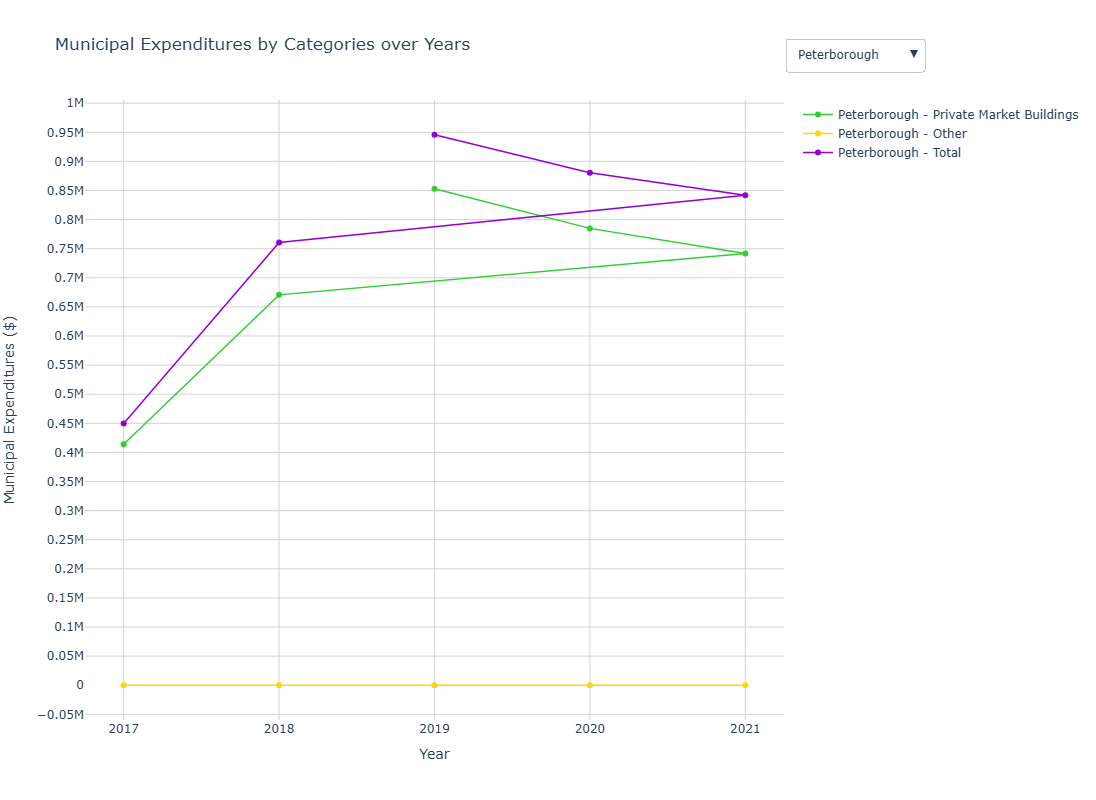

In [ ]:
municipally_funded_tenant_rent_df['Categories'] = municipally_funded_tenant_rent_df['Categories'].str.replace('\xa0', ' ')

color_map = {
    'Top-up in Existing Non-RGI Social Housing Unit': 'springgreen',
    'Social Housing Building with "Expired Operating Agreement"': '#228B22',  # Forest Green
    'Private Market Buildings': 'limegreen',
    'Other': 'gold',
    'Total': 'darkviolet'
}

fig_municipal_expenditures = go.Figure()

for city in municipally_funded_tenant_rent_df['City'].unique():
    city_data = municipally_funded_tenant_rent_df[municipally_funded_tenant_rent_df['City'] == city]
    for category in color_map.keys():
        category_data = city_data[city_data['Categories'] == category]
        if not category_data.empty:
            fig_municipal_expenditures.add_trace(go.Scatter(
                x=category_data['Year'],
                y=category_data['Municipal Expenditures, by Type($)'],
                mode='lines+markers',
                name=f"{city} - {category}",
                line=dict(color=color_map[category], width=1.5),
                visible=(city == municipally_funded_tenant_rent_df['City'].unique()[0])
            ))

visibility_settings = []
for city in municipally_funded_tenant_rent_df['City'].unique():
    visibility = [trace.name.startswith(city) for trace in fig_municipal_expenditures.data]
    visibility_settings.append(visibility)

fig_municipal_expenditures.update_layout(
    title='Municipal Expenditures by Categories over Years',
    xaxis_title='Year',
    yaxis_title='Municipal Expenditures ($)',
    yaxis=dict(tickmode='linear', tick0=0, dtick=50000, showgrid=True, gridcolor='lightgrey'),
    xaxis=dict(tickmode='linear', tick0=2010, dtick=1, showgrid=True, gridcolor='lightgrey'),
    plot_bgcolor='white',
    paper_bgcolor='white',
    width=1000,
    height=800,
    updatemenus=[
        {
            'buttons': [
                {
                    'label': city,
                    'method': 'update',
                    'args': [
                        {'visible': [trace.name.startswith(city) for trace in fig_municipal_expenditures.data]},
                        {'title': f"Municipal Expenditures by Categories over Years in {city}"}
                    ]
                } for city in municipally_funded_tenant_rent_df['City'].unique()
            ],
            'direction': 'down',
            'showactive': True,
            'x': 1.2,
            'y': 1.1
        }
    ]
)

fig_municipal_expenditures.show()

In [ ]:
centralized_waiting_list_inform_df.head()

,Year,Households with No Dependants,Households with Dependants,Senior Households,Total,City
0,2011,243.0,238.0,299.0,780.0,Cornwall
1,2012,242.0,186.0,281.0,709.0,Cornwall
2,2013,248.0,209.0,264.0,721.0,Cornwall
3,2014,276.0,184.0,276.0,736.0,Cornwall
4,2015,293.0,185.0,276.0,754.0,Cornwall


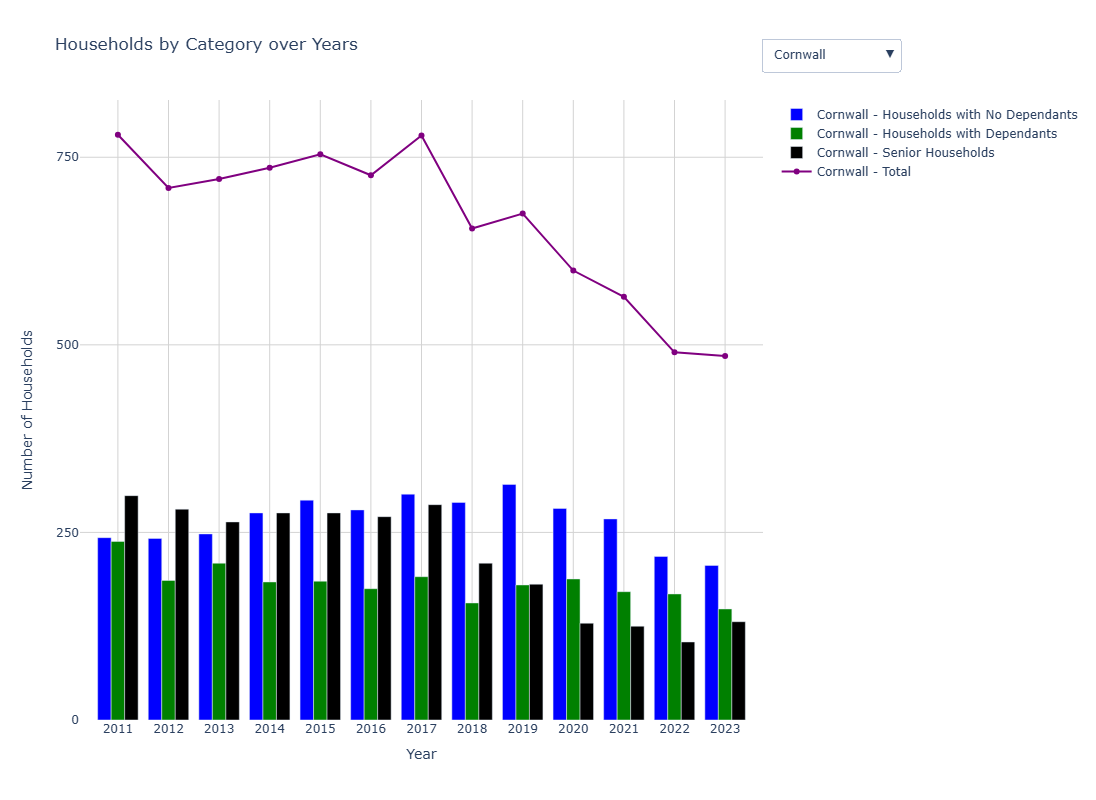

In [ ]:
color_map = {
    'Households with No Dependants': 'blue',
    'Households with Dependants ': 'green',
    'Senior Households': 'black',
    'Total': 'purple'
}

fig = go.Figure()

for city in centralized_waiting_list_inform_df['City'].unique():
    city_data = centralized_waiting_list_inform_df[centralized_waiting_list_inform_df['City'] == city]
    for category in ['Households with No Dependants', 'Households with Dependants ', 'Senior Households']:
        fig.add_trace(go.Bar(
            x=city_data['Year'],
            y=city_data[category],
            name=f"{city} - {category}",
            marker_color=color_map[category],
            visible=(city == centralized_waiting_list_inform_df['City'].unique()[0])
        ))

for city in centralized_waiting_list_inform_df['City'].unique():
    city_data = centralized_waiting_list_inform_df[centralized_waiting_list_inform_df['City'] == city]
    fig.add_trace(go.Scatter(
        x=city_data['Year'],
        y=city_data['Total'],
        mode='lines+markers',
        name=f"{city} - Total",
        line=dict(color=color_map['Total'], width=2),
        visible=(city == centralized_waiting_list_inform_df['City'].unique()[0])
    ))

visibility_settings = []
for city in centralized_waiting_list_inform_df['City'].unique():
    visibility = [trace.name.startswith(city) for trace in fig.data]
    visibility_settings.append(visibility)

fig.update_layout(
    title='Households by Category over Years',
    xaxis_title='Year',
    yaxis_title='Number of Households',
    barmode='group',
    yaxis=dict(tickmode='linear', tick0=0, dtick=250, showgrid=True, gridcolor='lightgrey'),
    xaxis=dict(tickmode='linear', tick0=2010, dtick=1, showgrid=True, gridcolor='lightgrey'),
    plot_bgcolor='white',
    paper_bgcolor='white',
    width=1000,
    height=800,
    updatemenus=[
        {
            'buttons': [
                {
                    'label': city,
                    'method': 'update',
                    'args': [
                        {'visible': visibility},
                        {'title': f"Households by Category over Years in {city}"}
                    ]
                } for city, visibility in zip(centralized_waiting_list_inform_df['City'].unique(), visibility_settings)
            ],
            'direction': 'down',
            'showactive': True,
            'x': 1.2,
            'y': 1.1
        }
    ]
)

fig.show()

In [ ]:
filtered_df = cwl_household_2020_onwards_df[
    (cwl_household_2020_onwards_df['Type of Households'] == 'TOTAL')
][[
    'Year',
    'Type of Households',
    'Number of new households added to the CWL',
    'Number of households removed from the CWL',
    'Households removed from the CWL - moved into RGI unit',
    'City'
]]

In [ ]:
filtered_df=filtered_df.drop(columns = "Type of Households")

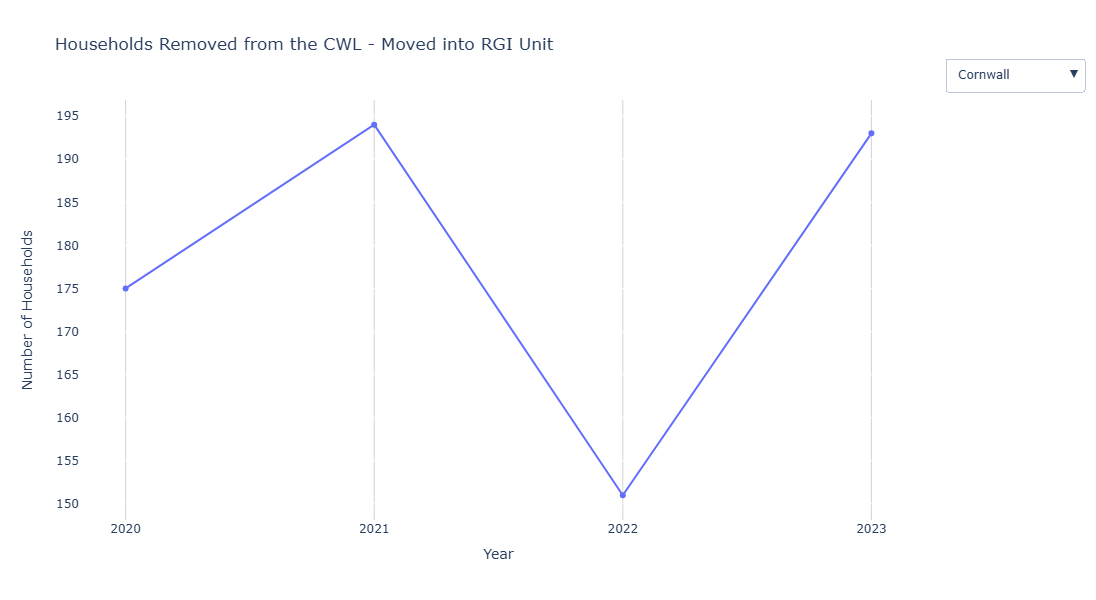

In [ ]:
fig2 = go.Figure()
for city in filtered_df['City'].unique():
    city_data = filtered_df[filtered_df['City'] == city]
    fig2.add_trace(go.Scatter(
        x=city_data['Year'],
        y=city_data['Households removed from the CWL - moved into RGI unit'],
        mode='lines+markers',
        name=city,
        visible=(city == filtered_df['City'].unique()[0])
    ))
fig2.update_layout(
    title='Households Removed from the CWL - Moved into RGI Unit',
    xaxis_title='Year',
    yaxis_title='Number of Households',
    plot_bgcolor='white',
    paper_bgcolor='white',
    width=1000,
    height=600,
    xaxis=dict(tickmode='linear', tick0=2010, dtick=1, showgrid=True, gridcolor='lightgrey'),
    updatemenus=[
        {
            'buttons': [
                {
                    'label': city,
                    'method': 'update',
                    'args': [
                        {'visible': [trace.name == city for trace in fig2.data]},
                        {'title': f'Households Removed from the CWL - Moved into RGI Unit in {city}'}
                    ]
                } for city in filtered_df['City'].unique()
            ],
            'direction': 'down',
            'showactive': True,
            'x': 1.2,
            'y': 1.1
        }
    ]
)

fig2.show()

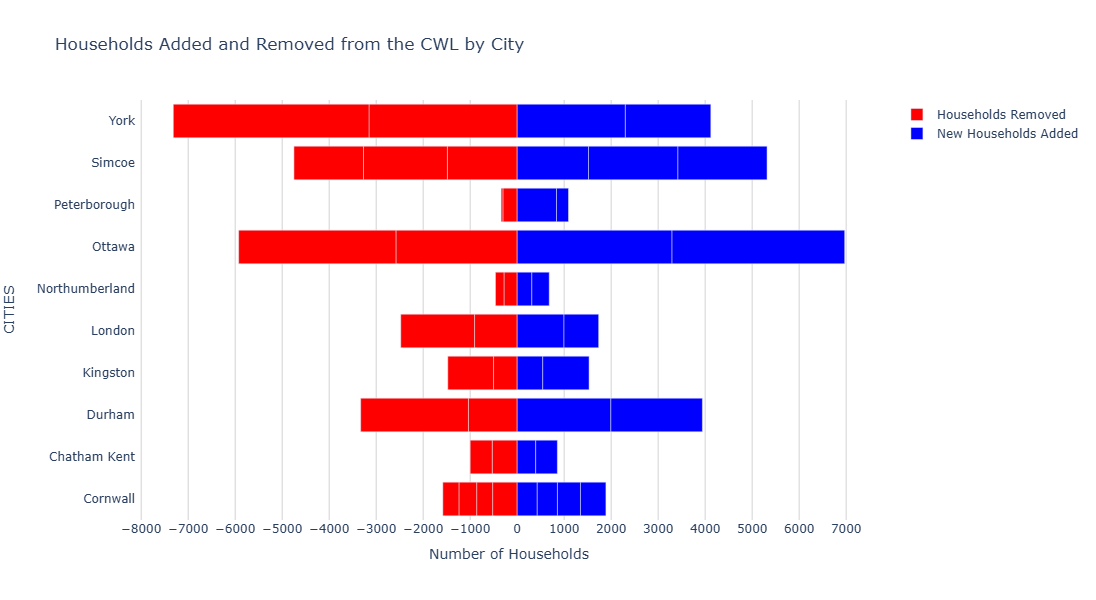

In [ ]:
filtered_df = cwl_household_2020_onwards_df[
    (cwl_household_2020_onwards_df['Type of Households'] == 'TOTAL')
][[
    'Year',
    'Type of Households',
    'Number of new households added to the CWL',
    'Number of households removed from the CWL',
    'Households removed from the CWL - moved into RGI unit',
    'City'
]]

filtered_df=filtered_df.drop(columns = "Type of Households")
fig1 = go.Figure()

fig1.add_trace(go.Bar(
    y=filtered_df['City'],
    x=-filtered_df['Number of households removed from the CWL'],
    name='Households Removed',
    orientation='h',
    marker_color='red'
))

fig1.add_trace(go.Bar(
    y=filtered_df['City'],
    x=filtered_df['Number of new households added to the CWL'],
    name='New Households Added',
    orientation='h',
    marker_color='blue'
))

fig1.update_layout(
    title='Households Added and Removed from the CWL by City',
    xaxis_title='Number of Households',
    yaxis_title='CITIES',
    barmode='relative',
    plot_bgcolor='white',
    paper_bgcolor='white',
    width=1000,
    height=600,
    xaxis=dict(
        tickmode='linear',
        tick0=0,
        dtick=1000,
        showgrid=True,
        gridcolor='lightgrey'
    )
)

fig1.show()

In [ ]:
forcasting_funding_df = excel_file.parse('FF')
forcasting_service_level_df = excel_file.parse('FSL')
forcasting_centralized_waiting_list_df = excel_file.parse('CWLF')

In [ ]:
forcasting_centralized_waiting_list_df.columns

Index(['Year', 'Total'], dtype='object')

In [ ]:
forcasting_centralized_waiting_list_df['Year'] = pd.to_datetime(forcasting_centralized_waiting_list_df['Year'], format='%Y')

forcasting_centralized_waiting_list_df.set_index(forcasting_centralized_waiting_list_df.columns[0], inplace=True) # THis is year column

forecast_results1 = {}
for column in forcasting_centralized_waiting_list_df.columns:
    df1 = forcasting_centralized_waiting_list_df[[column]].reset_index()
    df1.columns = ['ds', 'y']
    model = Prophet()
    model.fit(df1)
    future1 = model.make_future_dataframe(periods=10, freq='Y') #, include_history = False)
    forecast1 = model.predict(future1)
    forecast_results1[column] = forecast1[['ds', 'yhat']].set_index('ds')

14:11:55 - cmdstanpy - INFO - Chain [1] start processing
14:11:55 - cmdstanpy - INFO - Chain [1] done processing


In [ ]:
forecast_df1 = pd.concat(forecast_results1.values(), axis=1)
forecast_df1.columns = forecast_results1.keys()
forecast_df1.index = forecast_df1.index.year
forecast_df1.reset_index(inplace=True)
forecast_df1.rename(columns={forecast_df1.columns[0]: 'Year'}, inplace=True)

In [ ]:
forecast_df1=forecast_df1.drop(index=11) # removes 11th which is the predicted data for 2021

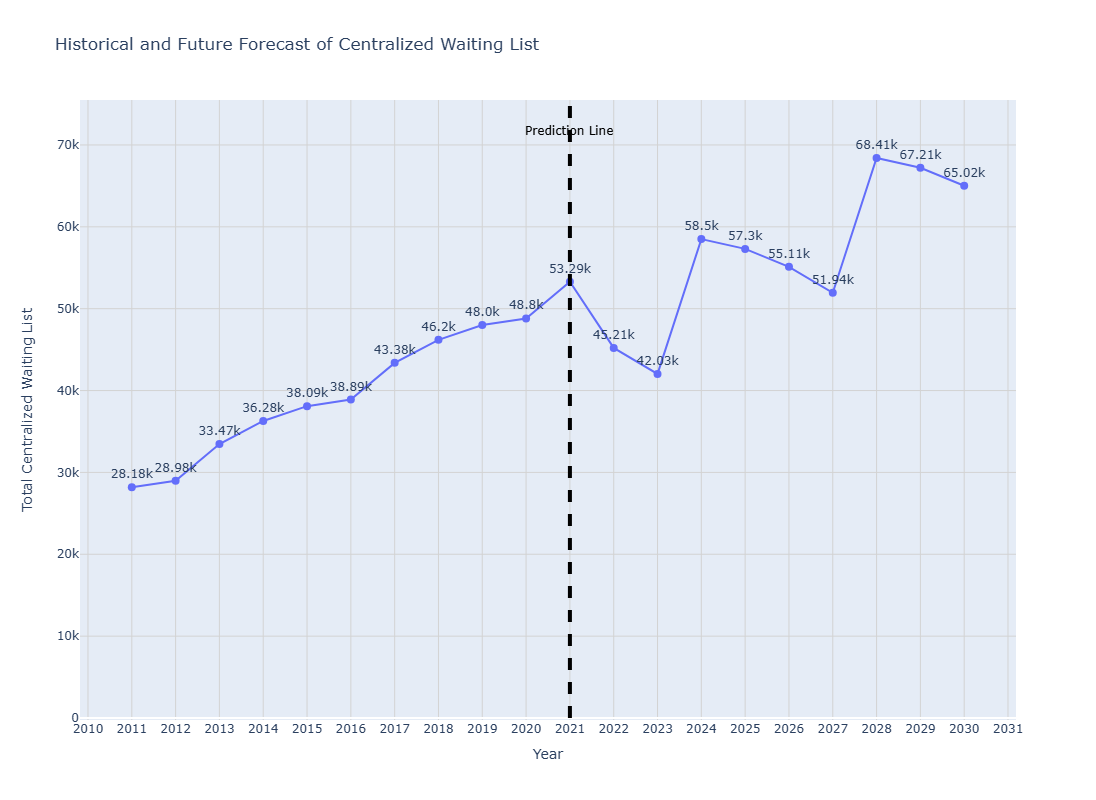

In [ ]:
fig2 = go.Figure()
fig2.add_scatter(
    x=forecast_df1['Year'],
    y=forecast_df1['Total'],
    mode='lines+markers+text',
    text=(((forecast_df1['Total']/ 1000).round(2)).astype(str) + "k"),
    textposition='top center',
    marker=dict(size=8, symbol='circle'),
    name='Total Data Points'
)

fig2.add_shape(
    type="line",
    x0=2021, x1=2021,
    y0=0, y1=forecast_df1['Total'].max() * 1.1,
    line=dict(color="Black", width=4, dash="dash"),
    name="Prediction Line"
)
fig2.add_annotation( x=2021, y=forecast_df1['Total'].max() * 1.05, text="Prediction Line", showarrow=False, font=dict(size=12, color="Black"), align="center" )
fig2.update_layout(
    title='Historical and Future Forecast of Centralized Waiting List',
    xaxis_title='Year',
    yaxis_title='Total Centralized Waiting List',
    width=1000,
    height=800,
    yaxis=dict(tickmode='linear', tick0=0, dtick=10000, showgrid=True, gridcolor='lightgrey'),
    xaxis=dict(
        tickmode='linear',
        tick0=2011,
        dtick=1,
        showgrid=True,
        gridcolor='lightgrey'
    )
)

fig2.show()


In [ ]:
forcasting_service_level_df['Year'] = pd.to_datetime(forcasting_service_level_df['Year'], format='%Y')
forcasting_service_level_df.set_index(forcasting_service_level_df.columns[0], inplace=True)
forecast_results1 = {}
for column in forcasting_service_level_df.columns:
    df1 = forcasting_service_level_df[[column]].reset_index()
    df1.columns = ['ds', 'y']
    model = Prophet()
    model.fit(df1)
    future1 = model.make_future_dataframe(periods=10, freq='Y', include_history = True)
    forecast1 = model.predict(future1)
    forecast_results1[column] = forecast1[['ds', 'yhat']].set_index('ds')

14:11:55 - cmdstanpy - INFO - Chain [1] start processing
14:11:56 - cmdstanpy - INFO - Chain [1] done processing
14:11:56 - cmdstanpy - INFO - Chain [1] start processing
14:11:56 - cmdstanpy - INFO - Chain [1] done processing


In [ ]:
forecast_df1 = pd.concat(forecast_results1.values(), axis=1)
forecast_df1.columns = forecast_results1.keys()

forecast_df1.index = forecast_df1.index.year

forecast_df1.reset_index(inplace=True)
forecast_df1.rename(columns={forecast_df1.columns[0]: 'Year'}, inplace=True)

In [ ]:
forecast_df1=forecast_df1.drop(index=11) # removes 11th which is the predicted data for 2021

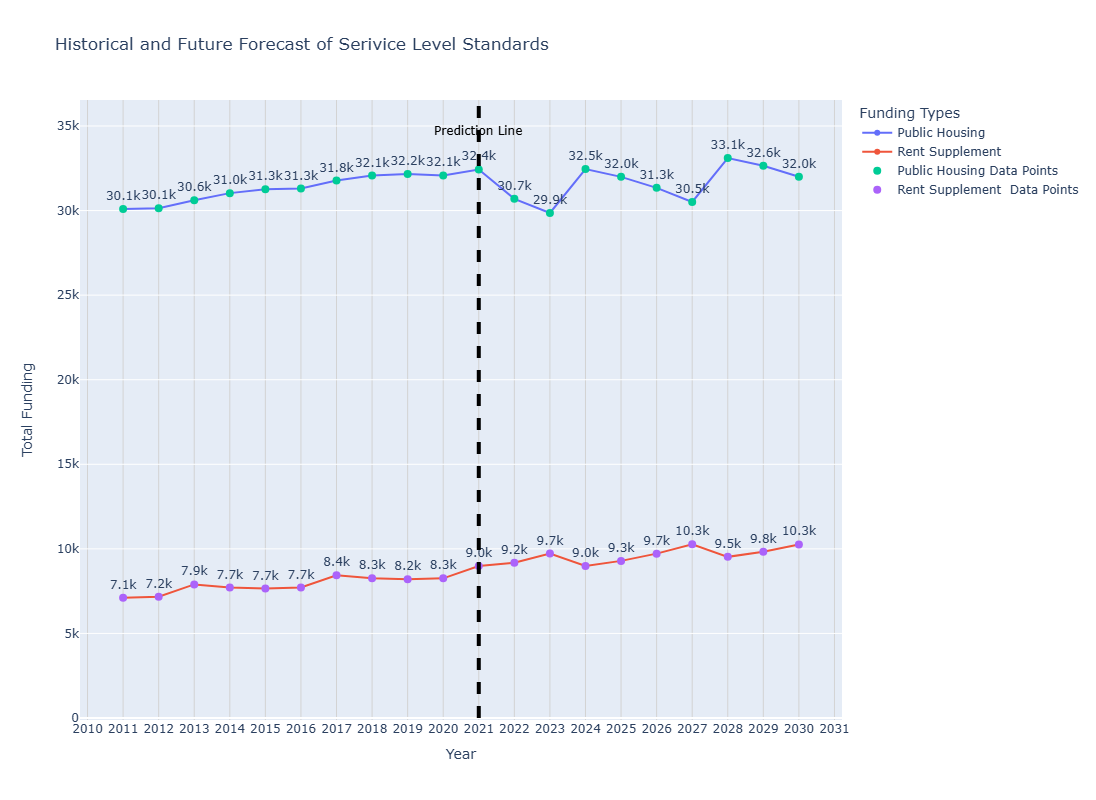

In [ ]:
fig = go.Figure()
fig = px.line(
    forecast_df1,
    x='Year',
    y=['Public Housing', 'Rent Supplement '],
    title='Forecasted Service Levels',
    labels={'value': 'Forecasted Value', 'variable': 'Service Type'},
    markers=True,
    text=None 
)

for column in ['Public Housing', 'Rent Supplement ']:
    fig.add_scatter(
        x=forecast_df1['Year'],
        y=forecast_df1[column],
        mode='markers+text',
        text=((forecast_df1[column]/1000).round(1).astype(str) + "k"),
        textposition='top center',
        marker=dict(size=8, symbol='circle'),
        name=f"{column} Data Points"
    )

fig.add_shape(
    type="line",
    x0=2021, x1=2021,
    y0=0, y1=forecast_df1['Public Housing'].max() * 1.1,
    line=dict(color="Black", width=4, dash="dash"),
    name="Prediction Line"
)
fig.add_annotation( x=2021, y=forecast_df1['Public Housing'].max() * 1.05, text="Prediction Line", showarrow=False, font=dict(size=12, color="Black"), align="center" )

fig.update_layout(
    title='Historical and Future Forecast of Serivice Level Standards',
    xaxis_title='Year',
    yaxis_title='Total Funding',
    legend_title_text='Funding Types',
    width=1100,
    height=800,
    xaxis=dict(
        tickmode='linear',
        tick0=2011,
        dtick=1,
        showgrid=True,
        gridcolor='lightgrey'
    )
)

fig.show()

In [ ]:
forcasting_funding_df.columns

Index(['Year', 'Public housing', 'Rent supplement', 'Limited dividend',
       'Sect 26', 'Sect 27', 'Sect 95 - PNP', 'Sect 95 - MNP',
       'Provincial reformed', 'Post 85 urban native', 'Pre-86 urban native'],
      dtype='object')

In [ ]:
forcasting_funding_df['Year'] = pd.to_datetime(forcasting_funding_df['Year'], format='%Y')
forcasting_funding_df.set_index(forcasting_funding_df.columns[0], inplace=True)
forecast_results = {}
for column in forcasting_funding_df.columns:
    df = forcasting_funding_df[[column]].reset_index()
    df.columns = ['ds', 'y']
    model = Prophet()
    model.fit(df)
    future = model.make_future_dataframe(periods=10, freq='Y', include_history = True)
    forecast = model.predict(future)
    forecast_results[column] = forecast[['ds', 'yhat']].set_index('ds')

14:11:58 - cmdstanpy - INFO - Chain [1] start processing
14:11:58 - cmdstanpy - INFO - Chain [1] done processing
14:11:58 - cmdstanpy - INFO - Chain [1] start processing
14:11:58 - cmdstanpy - INFO - Chain [1] done processing
14:11:59 - cmdstanpy - INFO - Chain [1] start processing
14:11:59 - cmdstanpy - INFO - Chain [1] done processing
14:11:59 - cmdstanpy - INFO - Chain [1] start processing
14:11:59 - cmdstanpy - INFO - Chain [1] done processing
14:12:00 - cmdstanpy - INFO - Chain [1] start processing
14:12:00 - cmdstanpy - INFO - Chain [1] done processing
14:12:00 - cmdstanpy - INFO - Chain [1] start processing
14:12:00 - cmdstanpy - INFO - Chain [1] done processing
14:12:01 - cmdstanpy - INFO - Chain [1] start processing
14:12:01 - cmdstanpy - INFO - Chain [1] done processing
14:12:01 - cmdstanpy - INFO - Chain [1] start processing
14:12:01 - cmdstanpy - INFO - Chain [1] done processing
14:12:02 - cmdstanpy - INFO - Chain [1] start processing
14:12:02 - cmdstanpy - INFO - Chain [1]

In [ ]:
forecast_df = pd.concat(forecast_results.values(), axis=1)
forecast_df.columns = forecast_results.keys()
forecast_df.index = forecast_df.index.year
forecast_df.reset_index(inplace=True)
forecast_df.rename(columns={forecast_df.columns[0]: 'Year'}, inplace=True)

In [ ]:
forecast_df=forecast_df.drop(index=11) # removes 11th which is the predicted data for 2021

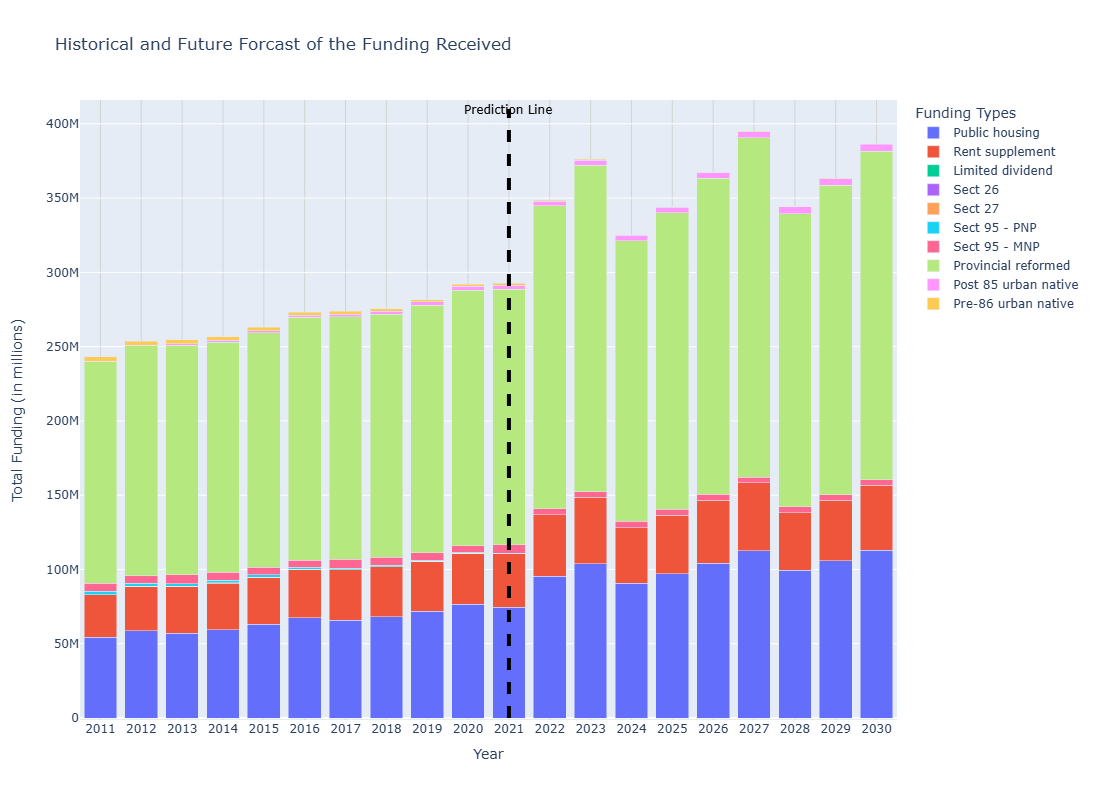

In [ ]:
fig = go.Figure
fig = px.bar(forecast_df, 
             x='Year', 
             y=forecast_df.columns[1:], 
             title='Schedule of Funding Forecast', 
             labels={'value': 'Total Funding (in millions)'}, 
             barmode='stack')

fig.add_shape(
    type="line",
    x0=2021, x1=2021,
    y0=0, y1=410000000,
    line=dict(color="Black", width=4, dash="dash"),
    name="Prediction Line"
)
fig.add_annotation( x=2021, y=410000000, text="Prediction Line", showarrow=False, font=dict(size=12, color="Black"), align="center" )


fig.update_layout(
    title = 'Historical and Future Forcast of the Funding Received',
    xaxis_title='Year', 
    yaxis_title='Total Funding (in millions)', 
    legend_title_text='Funding Types', 
    width=1000, 
    height=800,
    xaxis=dict(
        tickmode='linear',
        tick0=2011,
        dtick=1,
        showgrid=True,
        gridcolor='lightgrey'
    )
) 
fig.show()